---
title: "Dataset Characterization Notebook 1"
date: 2026-04-19
author: Andrei Akopian
---

Imports

In [29]:
import pandas as pd
import seaborn as sns

In [2]:
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[2]
sys.path.append(str(github_root))

In [3]:
DIAGNOSIS_RECORDS_TRAIN = "../../data/diagnosis_records_train.csv"
PARTICIPANT_DATA_TRAIN = "../../data/participant_data_train.csv"
WEARABLE_DATA_TRAIN = "../../data/wearable_data_train.csv" 

Loading the Dataset

In [4]:
diagnosis_records_train = pd.read_csv(DIAGNOSIS_RECORDS_TRAIN)
participant_data_train = pd.read_csv(PARTICIPANT_DATA_TRAIN)
wearable_data_train = pd.read_csv(WEARABLE_DATA_TRAIN)

In [5]:
diagnosis_records_train

,ID,HOSPITAL_CLINIC,HCP,date,diagnosis
0,380,L_000130637,D_00612441,2022-04-26,Stomach Aches
1,1372,L_000758610,D_00910403,2019-03-16,flu
2,4497,L_000649255,D_02265924,2020-03-17,Sinus infection
3,151,L_000041260,D_01926201,2025-03-26,influenza a
4,2185,L_000641795,D_01556668,2024-02-08,diarrhea
...,...,...,...,...,...
11532,4375,L_000825198,D_02207707,2025-01-13,INFLUENZA
11533,1091,L_000774357,D_00725720,2024-02-29,Dermatitis
11534,6494,L_000911279,D_00466434,2019-05-20,Central Sleep Apnea (CSA)
11535,3731,L_000435370,D_02300982,2023-09-09,BRONCHITIS


In [6]:
participant_data_train.shape

(20000, 26)

## Participant Ages

Text(0.5, 1.0, 'Ages')

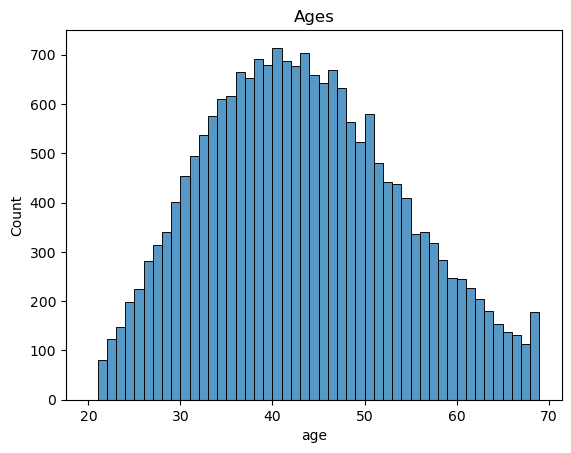

In [37]:
sns.histplot(participant_data_train['age'], bins=[a for a in range(20, 70)]).set_title("Ages")

Does wearing health wearables affect health?

In [21]:
((participant_data_train["outcome"] == 1) & (participant_data_train["engagement_level"] > 0)).sum() / (participant_data_train["engagement_level"] > 0).sum()

np.float64(0.05815748841996912)

In [24]:
(participant_data_train["outcome"] == 1).sum() / participant_data_train.shape[0]

np.float64(0.08095)

In [38]:
set(participant_data_train["age_bin"])

{'0-24', '25-44', '45-64', '65+'}

### Diseases

In [44]:
(participant_data_train['sex'] == "F").sum()

np.int64(10025)

## Diagnosis

In [7]:
len(set(diagnosis_records_train["HCP"]))

11520

## Wearable Data

In [28]:
wearable_data_train["timestamp"]

0         2016-01-04
1         2016-01-05
2         2016-01-07
3         2016-01-08
4         2016-01-10
             ...    
507859    2016-12-06
507860    2016-12-07
507861    2016-12-11
507862    2016-12-18
507863    2016-12-24
Name: timestamp, Length: 507864, dtype: object

In [27]:
len(set(wearable_data_train["timestamp"]))

365

In [9]:
wearable_data_train["afib_daily"].value_counts()

afib_daily
0    497272
1     10592
Name: count, dtype: int64

In [10]:
wearable_data_train['app_version'].value_counts()

app_version
5.1.0    116968
5.0.0     94031
5.0.1     91207
4.4.0     64607
4.3.1     54645
4.3.0     37751
4.2.1     22779
4.2.0     17484
4.1.0      8392
Name: count, dtype: int64

In [47]:
wearable_data_train.shape

(507864, 33)

In [49]:
wearable_data_train['exercise_code'].value_counts()

exercise_code
2.0    21421
1.0    20079
0.0    19693
3.0    16013
4.0    15044
5.0    10147
Name: count, dtype: int64